In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr 
from scipy import stats

###############################################################################
# Paths & constants
###############################################################################
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow")
EEG_ROOT   = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow")

FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

OUT_TRIALS  = Path("trial_level_cca_slow.csv")
OUT_SUBJECT = Path("subject_level_cca_slow.csv")
OUT_WEIGHTS = Path("cca_weights_slow")


#SUBJECTS = np.setdiff1d(np.arange(35, 59), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
SUBJECTS = np.setdiff1d(np.arange(32, 99), [32, 37, 53, 61, 66, 78, 84, 90, 94, 96])
WIN_OFFSET1 = 200                  # discard first 2 s
WIN_OFFSET2 = 101                  # discard last 1.01 s

###############################################################################
# Helper functions
###############################################################################

def normalise_eeg(x: np.ndarray) -> np.ndarray:
    """Centre each channel and scale so Σ x² = 1 over time×channels."""
    x = x - x.mean(axis=0, keepdims=True)
    scale = np.sqrt(np.mean(x**2))
    return x / scale


def cca_corr(eeg: np.ndarray, pupil: np.ndarray) -> float:
    """Canonical correlation (single component)."""
    cca = CCA(n_components=1, max_iter=1000, scale=False, tol=1e-6)
    cca.fit(eeg, pupil)
    u, v = cca.transform(eeg, pupil)
    return float(np.corrcoef(u[:, 0], v[:, 0])[0, 1])

def candidate_lags_units(step_ms=100, max_ms=2000):
    # Your code uses 10 ms units (lag_ms = shift*10)
    step_units = step_ms // 10
    max_units  = max_ms  // 10
    return list(range(-max_units, max_units + 1, step_units))

SHIFTS = candidate_lags_units(step_ms=100, max_ms=1500)


In [2]:
def load_all_trials(
        sub: int,
        eeg_root: Path = EEG_ROOT,
        pupil_root: Path = PUPIL_ROOT,
        min_len: int = 40,
        max_len_diff: int = 30,
) -> list[tuple[np.ndarray, np.ndarray, dict]]:
    """
    Load *all* valid EEG-pupil trial pairs for one subject.

    Parameters
    ----------
    sub : int
        Numeric subject ID (e.g. 42).
    eeg_root, pupil_root : Path
        Roots of the pre-processed EEG and pupil folders.
    min_len : int
        Minimum number of samples a pupil trace must have to be accepted.
    max_len_diff : int
        Reject trial if |len(pupil)-len(eeg)| exceeds this.
    Returns
    -------
    trials : list of (eeg, pupil_z, meta)
        * eeg        - (T × n_channels) float64, already centred/scaled
        * pupil_z    - (T × 1) float64, per-trial z-scored
        * meta       - dict with subject/condition/load/epoch
    """
    trials = []
    sub_tag = f"sub-{sub:03d}"
    eeg_sub  = eeg_root   / sub_tag
    pupil_sub = pupil_root / sub_tag

    if not eeg_sub.exists():
        print(f"{sub_tag}: EEG folder missing - skipped")
        return trials

    # iterate condition (“control” / “memory”) and load (“05” / “09” / “13”)
    for cond_path in sorted(eeg_sub.iterdir()):
        if not cond_path.is_dir():
            continue
        for load_path in sorted(cond_path.iterdir()):
            if not load_path.is_dir():
                continue

            # matching pupil directory
            pupil_path = pupil_sub / cond_path.name / load_path.name
            if not pupil_path.exists():
                continue

            eeg_epochs   = sorted(load_path.glob("trial_*.csv"))
            pupil_epochs = sorted(pupil_path.glob("trial_*.csv"))
            common = {f.name for f in eeg_epochs} & {f.name for f in pupil_epochs}
            if not common:
                continue

            for fname in sorted(common):
                eeg_df = pd.read_csv(load_path / fname, comment="#", index_col=0)
                pupil_df = pd.read_csv(pupil_path / fname, comment="#", skiprows=1,
                                       names=["time", "diameter_z"], index_col=0)

                eeg   = eeg_df.values.astype(float)
                pupil = pupil_df["diameter_z"].values.astype(float)

                # basic validity checks
                if len(pupil) < min_len or abs(len(pupil) - len(eeg)) > max_len_diff:
                    continue

                # normalise signals ---------------------------------------- now do it after trimming shifted trials
                #eeg_norm = normalise_eeg(eeg)           # your helper from before
                #pupil_z  = ((pupil - pupil.mean()) / pupil.std(ddof=0))

                # same number of samples
                T = min(len(eeg), len(pupil))
                eeg = eeg[0:T, :]  # (T × n_channels)
                pupil  = pupil[0:T].reshape(-1, 1)

                meta = {
                    "subject":   sub_tag,
                    "condition": cond_path.name,
                    "load":      int(load_path.name),
                    "epoch":     fname
                }
                trials.append((eeg, pupil, meta))

    return trials

from typing import List, Tuple
import numpy as np

def split_trials_by_condition(
        trials: List[Tuple[np.ndarray, np.ndarray, dict]],
        memory_label: str = "memory",
        control_label: str = "control"
) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into memory-condition and control-condition sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'condition'.
    memory_label : str
        The value of meta['condition'] that marks a memory trial.
    control_label : str
        The value of meta['condition'] that marks a control trial.

    Returns
    -------
    memory_trials  : list[tuple]
    control_trials : list[tuple]
    """
    memory_trials  = []
    control_trials = []

    for eeg, pupil, meta in trials:
        cond = meta.get("condition", "").lower()
        if cond == memory_label:
            memory_trials.append((eeg, pupil, meta))
        elif cond == control_label:
            control_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown condition label: {cond}")

    return memory_trials, control_trials

def split_trials_by_load(trials: List[Tuple[np.ndarray, np.ndarray, dict]]
                         ) -> Tuple[List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]], List[Tuple[np.ndarray, np.ndarray, dict]]]:
    """
    Separate a mixed list of (eeg, pupil, meta) trial tuples into 05, 09 and 13 load sub-lists.

    Parameters
    ----------
    trials : list of tuples
        Each tuple = (eeg_array, pupil_array, meta_dict).
        meta_dict must contain a key 'load'.

    Returns
    -------
    load_05_trials  : list[tuple]
    load_09_trials  : list[tuple]
    load_13_trials  : list[tuple]
    """
    load_05_trials = []
    load_09_trials = []
    load_13_trials = []

    for eeg, pupil, meta in trials:
        load = meta.get("load")
        if load == 5:
            load_05_trials.append((eeg, pupil, meta))
        elif load == 9:
            load_09_trials.append((eeg, pupil, meta))
        elif load == 13:
            load_13_trials.append((eeg, pupil, meta))
        else: raise ValueError(f"Unknown load label: {load}")

    return load_05_trials, load_09_trials, load_13_trials


In [3]:

from typing import List, Tuple, Optional, Dict

# trials  : list of (eeg, pupil_z, meta)   -- the tuples returned by load_all_trials
# shift   : integer sample shift (best_shift)
# win     : slice or None                  -- cropping window (set to None if the
#                                            trials are already pre-trimmed)
def concat_trials(
    trials: List[Tuple[np.ndarray, np.ndarray, dict]],
    shift: int = 0,  # samples; positive = EEG delayed (EEG after pupil)
    trim=None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Concatenate trials for CCA without circular wrap.

    Returns
    -------
    X : ndarray, shape (Σ T_eff, n_channels)   # EEG
    Y : ndarray, shape (Σ T_eff, 1)            # pupil
    """
    X_blocks, Y_blocks = [], []
    if trim is not None:
        target_trim_samp = trim // 10   # 5000 ms → 500 samples at 100 Hz
        extra_samp = max(0, (target_trim_samp - abs(shift)) // 2)
        #print(f"Lag is {shift} samples. Trimming {extra_samp} samples from each end after lag adjustment")

    for eeg, pupil_z, _ in trials:
        # Ensure 1D/2D shapes: EEG (T, C), pupil (T, 1)
        if eeg.ndim == 1:
            eeg = eeg[:, None]
        if pupil_z.ndim == 1:
            pupil_z = pupil_z[:, None]

        T = min(len(eeg), len(pupil_z))
        if T == 0:
            print("Warning: zero-length trial encountered - skipped")
            continue

        # Optional common window first (keeps boundaries away)
        start = WIN_OFFSET1
        stop  = T - WIN_OFFSET2
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]
        Tw = len(eeg_w)

        # Apply lag by asymmetric trimming (no roll, no wrap)
        # Positive shift => EEG delayed => drop 'shift' from EEG start and pupil end
        # Negative shift => EEG advanced => drop '-shift' from pupil start and EEG end
        if shift >= 0:
            if Tw <= shift: continue  # nothing left after lag
            eeg_seg   = eeg_w[shift:]             # drop early EEG
            pupil_seg = pupil_w[:Tw - shift]      # drop late pupil
        else:
            s = -shift
            if Tw <= s: continue
            eeg_seg   = eeg_w[:Tw - s]            # drop late EEG
            pupil_seg = pupil_w[s:]               # drop early pupil

        if trim is not None:
            Lcur = int(len(eeg_seg))
            if extra_samp > 0:
                extra_eff = int(min(extra_samp, max(0, (Lcur - 2) // 2)))
                if extra_eff > 0:
                    eeg_seg   = eeg_seg[extra_eff : Lcur - extra_eff]
                    pupil_seg = pupil_seg[extra_eff : Lcur - extra_eff]

        eeg_seg = normalise_eeg(eeg_seg)           # your helper from before
        pupil_seg = ((pupil_seg - pupil_seg.mean()) / pupil_seg.std(ddof=0))

        # Shapes now match
        X_blocks.append(eeg_seg)
        Y_blocks.append(pupil_seg)

    if not X_blocks:
        print("Warning: no valid trials after concatenation - returning empty arrays")
        return np.empty((0, trials[0][0].shape[-1])), np.empty((0, 1))

    X = np.vstack(X_blocks)
    Y = np.vstack(Y_blocks)
    return X, Y

def iterate_trials(trials, shift):
    """
    Yield (eeg_aligned, pupil_aligned, meta) one by one, with no circular wrap.

    Conventions
    -----------
    - `shift` in samples, along time axis (axis=0).
    - shift >= 0  → EEG delayed  → drop early EEG, drop late pupil
    - shift <  0  → EEG advanced → drop late EEG, drop early pupil
    """
    for eeg, pupil_z, meta in trials:
        # Window first
        T = min(len(eeg), len(pupil_z))
        start = WIN_OFFSET1
        stop  = T - 50
        if stop <= start:
            print("Warning: collapsed window after trimming - skipped")
            continue  # window collapsed; skip this trial

        eeg_w   = eeg[start:stop]
        pupil_w = pupil_z[start:stop]

        # Ensure both have time along axis 0 and share the same window length
        Tw = len(eeg_w)
        
        if Tw == 0: continue

        if shift >= 0: # EEG delayed: drop early EEG, drop late pupil
            eeg_out   = eeg_w[shift:]           # works for 1D or 2D (time on axis 0)
            pupil_out = pupil_w[:Tw - shift]
        else:
            s = -shift # EEG advanced: drop late EEG, drop early pupil
            
            eeg_out   = eeg_w[:Tw - s]
            pupil_out = pupil_w[s:]

        eeg_out = normalise_eeg(eeg_out)           # your helper from before
        pupil_out = ((pupil_out - pupil_out.mean()) / pupil_out.std(ddof=0))

        yield eeg_out, pupil_out, meta.copy()

import pandas as pd
import json
from pathlib import Path

def save_cca_weights(cca, subject_tag, lag_ms, eeg_ch_names, condition, out_dir=Path("weights")):
    """
    Dump EEG & pupil canonical weights to CSV/JSON for one subject.

    Parameters
    ----------
    cca            : fitted sklearn.cross_decomposition.CCA
    subject_tag    : "sub-042"
    lag_ms         : e.g. -90
    eeg_ch_names   : list[str] same order as columns in your trial matrices
    out_dir        : destination folder (created if missing)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # ------- Pupil weight -> JSON ---------------------------------------
    w_pupil_og = float(cca.y_weights_[0, 0])   # scalar in 1-dim pupil case
    w_pupil = 1.0
    with open(out_dir / f"{subject_tag}_pupil_weight_{condition}_{lag_ms:+d}ms.json", "w") as fh:
        json.dump({"weight": w_pupil}, fh, indent=2)
    
    # ------- EEG weights -> tidy CSV ------------------------------------
    w_eeg = cca.x_weights_[:, 0] / w_pupil_og
    w_eeg = pd.Series(w_eeg, index=eeg_ch_names, name="weight")
    w_eeg.index.name = "channel"
    w_eeg.to_csv(out_dir / f"{subject_tag}_eeg_weights_{condition}_{lag_ms:+d}ms.csv")

    print(f"saved weights for {subject_tag} (lag {lag_ms:+d} ms)")

def search_best_lag(
            train_trials: List[Tuple[np.ndarray, np.ndarray, dict]],
            shifts: np.ndarray = SHIFTS,
            return_curve: bool = False,
            max_ms=None
    ) -> Tuple[float, int, Dict[int, float] | None]:
        
        r_per_shift: Dict[int, float] = {}
        for s in shifts:
            eeg, pupil = concat_trials(train_trials, shift=s, trim=max_ms)
            r_per_shift[s] = cca_corr(eeg, pupil)

        best_shift = max(r_per_shift, key=r_per_shift.get)
        best_corr  = r_per_shift[best_shift]

        if return_curve:
            return best_corr, best_shift, r_per_shift
        else:
            return best_corr, best_shift, None



In [4]:
from typing import List, Tuple
import numpy as np

# Type alias just for readability
TrialTuple = Tuple[np.ndarray, np.ndarray, dict]

def make_triplets_by_load(
    trials_cond: List[TrialTuple],
    condition_name: str = "memory",
    rng: np.random.Generator | None = None,
    verbose: bool = True,
) -> List[List[TrialTuple]]:
    """
    Build triplets from trials of a *single condition* (all 'memory' or all 'control').

    Strategy:
    1. Separate trials into load buckets (5, 9, 13).
    2. Create as many 'balanced' triplets as possible with exactly 1×5, 1×9, 1×13.
    3. Collect all leftover trials, shuffle them, form additional triplets of size 3.
    4. If leftover count mod 3 != 0, attach the last 1–2 trials to existing triplets.

    Returns
    -------
    triplets : list of lists
        Each inner list is a group of trials (size 3, occasionally 4–5 at the end).
    """
    if rng is None:
        rng = np.random.default_rng(7)

    if len(trials_cond) == 0:
        if verbose:
            print(f"[{condition_name}] No trials – returning empty triplet list.")
        return []

    # 1) Split by load: we reuse your helper
    load_05, load_09, load_13 = split_trials_by_load(trials_cond)
    load_05 = list(load_05)
    load_09 = list(load_09)
    load_13 = list(load_13)

    # Shuffle within each load bucket for randomness
    rng.shuffle(load_05)
    rng.shuffle(load_09)
    rng.shuffle(load_13)

    n05, n09, n13 = len(load_05), len(load_09), len(load_13)
    if verbose:
        print(f"[{condition_name}] trials per load: 5→{n05}, 9→{n09}, 13→{n13}")

    total = len(trials_cond)
    if total < 3:
        if verbose:
            print(f"[{condition_name}] < 3 trials total; returning one 'triplet' with all trials.")
        return [trials_cond[:] ]

    # 2) Balanced triplets: one of each load 5,9,13
    n_balanced = min(n05, n09, n13)
    triplets: List[List[TrialTuple]] = []

    for i in range(n_balanced):
        triplets.append([
            load_05[i],
            load_09[i],
            load_13[i],
        ])

    if verbose and n_balanced > 0:
        print(f"[{condition_name}] Created {n_balanced} balanced 5–9–13 triplets.")

    # 3) Collect leftovers after using balanced part
    leftovers: List[TrialTuple] = []
    leftovers.extend(load_05[n_balanced:])
    leftovers.extend(load_09[n_balanced:])
    leftovers.extend(load_13[n_balanced:])

    # Sanity: also catch any weird loads if present
    # (in case some trials had load != 5/9/13)
    for tr in trials_cond:
        load = tr[2].get("load", None)
        if load not in (5, 9, 13):
            leftovers.append(tr)

    # Remove duplicates (in case weird loads were also in 05/09/13 lists)
    if leftovers:
        # Use object id to deduplicate while keeping order
        seen = set()
        unique_leftovers = []
        for tr in leftovers:
            oid = id(tr)
            if oid not in seen:
                seen.add(oid)
                unique_leftovers.append(tr)
        leftovers = unique_leftovers

    rng.shuffle(leftovers)
    n_left = len(leftovers)

    if verbose and n_left > 0:
        print(f"[{condition_name}] {n_left} leftover trials after balanced triplets.")

    # 4) Make extra triplets purely from leftovers (any load mix)
    q, r = divmod(n_left, 3)
    idx = 0
    for _ in range(q):
        triplets.append([
            leftovers[idx],
            leftovers[idx + 1],
            leftovers[idx + 2],
        ])
        idx += 3

    remaining = leftovers[idx:]  # length r ∈ {0, 1, 2}

    # 5) Attach remaining 1–2 trials to existing triplets (or one new group)
    if remaining:
        if not triplets:
            # No triplets yet; just one small group with 1–2 elements
            triplets.append(list(remaining))
        else:
            for i, tr in enumerate(remaining):
                triplets[i % len(triplets)].append(tr)

        if verbose:
            print(f"[{condition_name}] Attached {len(remaining)} leftover trial(s) to existing triplets.")

    if verbose:
        sizes = [len(t) for t in triplets]
        print(f"[{condition_name}] Final triplet counts: {len(triplets)} groups, sizes={sizes}")

    return triplets

def loto_folds_from_triplets(triplets: List[List[TrialTuple]]):
    folds = []
    for i, test_group in enumerate(triplets):
        train_group = [tr for j, g in enumerate(triplets) if j != i for tr in g]
        folds.append({
            "train": train_group,
            "test":  test_group,
        })
    return folds



In [5]:
# ==== add below your helpers in cca_simulation2_script.py =====================
from typing import List, Tuple
import numpy as np
import pandas as pd

def ridge_wx(X: np.ndarray, y: np.ndarray, lam: float, eps: float = 1e-12, normalise: bool = False ) -> np.ndarray:
    """
    Return ridge-regression weights w for y ≈ Xw.

    Same covariance-style formulation as before, but:
    * no softmax
    * optional L2 normalisation if normalise=True (default False).
    """
    # centre like np.cov does
    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean()
    n  = Xc.shape[0]
    Sxx = (Xc.T @ Xc) / max(n - 1, 1)      # ddof=1 covariance
    Sxy = (Xc.T @ yc) / max(n - 1, 1)

    A = Sxx + lam * np.eye(Sxx.shape[0])
    w = np.linalg.solve(A, Sxy)

    return w
    

def corr_with_weights(X: np.ndarray, y: np.ndarray, w: np.ndarray, return_p: bool = False):
    u = X @ w
    u = np.asarray(u).ravel()
    y = np.asarray(y).ravel()

    # constant signals → Pearson undefined
    if u.std(ddof=0) == 0 or y.std(ddof=0) == 0:
        return (np.nan, np.nan) if return_p else np.nan

    r, p = pearsonr(u, y)  # true Pearson r + p-value

    return (float(r), float(p)) if return_p else float(r)

def mse_with_weights(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    """
    Mean squared error between y and Xw.
    Assumes X, y already preprocessed by concat_trials.
    """
    y_hat = X @ w
    return float(np.mean((y_hat - y) ** 2))


# ---------------- per-(lag, λ) training step ---------------------------------
def fit_at_shift_lambda(trials: List[dict], shift_samples: int, lam: float, trim_ms: int) -> Tuple[np.ndarray, float]:
    """
    Fit weights on concatenated TRAIN trials aligned with the given shift.
    Returns (w, train_mse, r_train).
    """
    X_tr, y_tr = concat_trials(trials, shift=shift_samples, trim=trim_ms)

    if len(y_tr) == 0:
        return np.zeros(trials[0]['X'].shape[1]), np.nan
    #w_zoo = ridge_cca_wx_zoo(X_tr, y_tr, lam)

    w_ridge = ridge_wx(X_tr, y_tr, lam, normalise=False)
    train_mse = mse_with_weights(X_tr, y_tr, w_ridge)

    r_train = corr_with_weights(X_tr, y_tr, w_ridge)
    return w_ridge, train_mse, r_train

def evaluate_on_trials(trials: List[dict], shift_samples: int, w: np.ndarray, trim_ms: int) -> float:
    """Correlation on a (TRAIN or TEST) split using fixed shift and weights."""
    X_te, y_te = concat_trials(trials, shift=shift_samples, trim=trim_ms)
    if len(y_te) == 0:
        return np.nan
    #return corr_with_weights(X_te, y_te, w)
    return mse_with_weights(X_te, y_te, w), corr_with_weights(X_te, y_te, w)

In [6]:
def lag_corr_curve(trials, lam, shifts, trim_ms):
    """
    Compute correlation vs lag for a fixed λ on a given set of trials.
    """
    rs = []
    for s in shifts:
        _, _, r, _ = fit_at_shift_lambda(trials, int(s), lam, trim_ms)
        rs.append(r)
    return np.array(shifts) * 10, np.array(rs)   # convert to ms


In [ ]:
import matplotlib.pyplot as plt

# best_shift_by_sub = {}  # best shift per subject
SHIFTS = candidate_lags_units(step_ms=10, max_ms=1500)
rows_subject = [] 
best_shift_by_sub = []
trim_ms = 100 # TODO fix later
#LAMBDAS = np.logspace(-3, 1.5, 15)
lambdas = [0, 0.01, 0.1, 1, 10, 100]

DEBUG_SUBJ = [80]

for subj in SUBJECTS:
    print(f"Processing subject {subj:02d}...")
    cv_summaries = []  # per-(λ) summaries
    all_trials = load_all_trials(subj)                         # list of (eeg, pupil)
    trials_memory, trials_control = split_trials_by_condition(all_trials)
    print(f"  Loaded {len(trials_memory)} memory trials")
    loads_mem = [meta["load"] for (_, _, meta) in trials_memory]
    print(f"  Memory loads counts: 5={loads_mem.count(5)}, 9={loads_mem.count(9)}, 13={loads_mem.count(13)}")


    rng = np.random.default_rng(42 + subj)
    mem_triplets = make_triplets_by_load(trials_memory, condition_name="memory", rng=rng)

    print(f"  Number of triplets: {len(mem_triplets)}")
    print(f"  Triplet sizes: {[len(t) for t in mem_triplets]}")

    folds = loto_folds_from_triplets(mem_triplets)
    if not folds:
        print(f"Subject {subj:02d}: not enough trials to form triplets - skipping trial-level CCA.")
        continue

    for lam in lambdas:
        print(f"  Lambda {lam}...")
        fold_rows = []
        train_rss, test_rss = [], []
        train_mses, test_mses = [], []

        for fold_idx, fold in enumerate(folds):
            print(f"  Fold {fold_idx+1}/{len(folds)}...")
            train_trials  = fold["train"]
            test_trials   = fold["test"]
            
            # 1) search best lag on TRAIN for this λ (MAXIMISE train correlation)
            best_shift, best_train_mse, rs_best, best_w = None, np.inf, -np.inf, None
            for s in SHIFTS:
                w_s, mse_tr, rs_tr = fit_at_shift_lambda(train_trials, int(s), lam, trim_ms)
                
                if np.isfinite(rs_tr) and rs_tr > rs_best:
                    best_train_mse, best_shift, rs_best, best_w = mse_tr, int(s), rs_tr, w_s
                
            # 2) evaluate on TEST using best (lag, w)
            mse_te, rs_te = evaluate_on_trials(test_trials, best_shift, best_w, trim_ms)

            fold_rows.append({
                "lam": lam, "shift": best_shift,
                "train_mse": best_train_mse, "test_mse": mse_te,
                "r_train": rs_best, "r_test": rs_te,
                "n_train": len(train_trials), "n_test": len(test_trials),
            })
            train_rss.append(rs_best);  test_rss.append(rs_te)
            train_mses.append(best_train_mse); test_mses.append(mse_te)

        cv_summaries.append({
            "lam": lam,
            "mean_train_r": float(np.nanmean(train_rss)),
            "mean_test_r": float(np.nanmean(test_rss)),
            "mean_train_mse": float(np.nanmean(train_mses)),
            "mean_test_mse": float(np.nanmean(test_mses)),
            "per_fold": fold_rows,
        })

    print("\n[Subject", subj, "] CV summary by lambda:")
    for cs in cv_summaries:
        print(f"  λ={cs['lam']:>6} | "
            f"train_r={cs['mean_train_r']:+.3f} | "
            f"test_r={cs['mean_test_r']:+.3f} | "
            f"train_mse={cs['mean_train_mse']:.4f} | "
            f"test_mse={cs['mean_test_mse']:.4f}")


    # pick λ with LOWEST mean TEST MSE (tie-breaker: smaller λ)
    ordered_results = sorted(cv_summaries, key=lambda c: (c["mean_test_mse"], c["lam"]))
    best = ordered_results[0]
    print(f"\n[Subject {subj}] Best λ = {best['lam']}, mean_test_mse = {best['mean_test_mse']:.4f}, mean_test_r = {best['mean_test_r']:+.3f}")


    # ------- recompute DEFINITIVE lag + weights at the chosen λ on ALL trials
    best_shift_all, best_mse_all, best_rs_all, best_w_all = None, np.inf, -np.inf, None
    for s in SHIFTS:
        w_s, mse_all, rs_all = fit_at_shift_lambda(trials_memory, int(s), best["lam"], trim_ms)

        if np.isfinite(rs_all) and rs_all > best_rs_all:
            best_mse_all, best_shift_all, best_rs_all, best_w_all = mse_all, int(s), rs_all, w_s

    final_fit = {
        "lambda": best["lam"],
        "best_shift": best_shift_all,
        "w": best_w_all,
        "train_mse_all": best_mse_all,
        "train_rs_all": best_rs_all,
        "cv_mean_test_mse": best["mean_test_mse"],
        "cv_mean_test_r": best["mean_test_r"],
        "cv_mean_train_mse": best["mean_train_mse"],
        "cv_mean_train_r": best["mean_train_r"],
        "cv_details": best["per_fold"],
    }

    X_all, y_all = concat_trials(trials_memory, shift=best_shift_all, trim=trim_ms)
    r_final, p_final = corr_with_weights(X_all, y_all, best_w_all, return_p=True)
    print(f"[Subject {subj}] FINAL Pearson r = {r_final:.3f}, p = {p_final:.3e}")
    print(f"  Var(y_all) = {y_all.var():.3f}")

    if subj == DEBUG_SUBJ:
        lam_star = best["lam"]
        lag_ms_star = int(final_fit["best_shift"]) * 10

        lags_ms, rs_curve = lag_corr_curve(trials_memory, lam_star, SHIFTS, trim_ms)

        plt.figure()
        plt.plot(lags_ms, rs_curve, marker="o")
        plt.axvline(lag_ms_star, linestyle="--", label=f"chosen lag = {lag_ms_star} ms")
        plt.xlabel("Lag (ms)")
        plt.ylabel("Correlation (train, memory trials)")
        plt.title(f"Subject {subj} – lag–corr curve (λ={lam_star})")
        plt.legend()
        plt.grid(True)
        plt.show()


    order_sx = pd.DataFrame(ordered_results)
    order_sx.drop(columns=["per_fold"], inplace=True)
    order_sx.to_csv(f"order_ridge_SLOW_k{subj}.csv", index=False)

    lam_star = final_fit["lambda"]
    best_shift_star = final_fit["best_shift"]
    lag_ms_star = int(best_shift_star) * 10
    w_star = final_fit["w"]
    train_mse_all_star = final_fit["train_mse_all"]
    mean_test_mse_star = final_fit["cv_mean_test_mse"]
    train_rs_all_star = final_fit["train_rs_all"]
    mean_test_rs_star = final_fit["cv_mean_test_r"]

    # ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
    # Choose lag+weights on ALL trials (search best lag over SHIFTS)
    best_mse0_all, rs_best_mse0, best_s0, w0_all = np.inf, -np.inf, None, None
    for s in SHIFTS:
        w_s, mse_all, rs_all = fit_at_shift_lambda(trials_memory, int(s), 0.0, trim_ms)
        if np.isfinite(rs_all) and rs_all > rs_best_mse0:
            best_mse0_all, rs_best_mse0, best_s0, w0_all = mse_all, rs_all, int(s), w_s


    lag_ms_zero = int(best_s0) * 10
    train_mse_all_zero = float(best_mse0_all)
    train_rs_all_zero = float(rs_best_mse0)

    # For fairness, compute MEAN TEST corr for λ=0 by *evaluating* this fixed (lag,w) on the folds,
    # but not using any CV information to select them.
    test_mses_zero, test_rs_zero = [], []
    for fold_idx, fold in enumerate(folds):
        test_trials   = fold["test"]
        mse_te0, r_te0 = evaluate_on_trials(test_trials, best_s0, w0_all, trim_ms)
        test_mses_zero.append(mse_te0)
        test_rs_zero.append(r_te0)
    mean_test_mse_zero = float(np.nanmean(test_mses_zero))
    mean_test_rs_zero = float(np.nanmean(test_rs_zero))

    rows_subject.append({
        "subject": subj,
        "lam_star": lam_star,
        "best_lag_ms_star": lag_ms_star,
        "train_mse_all_star": float(train_mse_all_star),
        "mean_test_mse_star": float(mean_test_mse_star),
        "train_r_all_star": float(train_rs_all_star),
        "mean_test_r_star": float(mean_test_rs_star),
        "w_star": w_star,
        "best_lag_ms_lam0": lag_ms_zero,
        "train_mse_all_lam0": train_mse_all_zero,
        "mean_test_mse_lam0": mean_test_mse_zero,
        "train_r_all_lam0": train_rs_all_zero,
        "mean_test_lam0": mean_test_rs_zero,
        "w_lam0": w0_all
    })
    r_final0, p_final0 = corr_with_weights(X_all, y_all, w0_all, return_p=True)
    print(f"[Subject {subj}] FINAL λ=0 Pearson r = {r_final0:.3f}, p = {p_final0:.3e}")
    print(f"  Var(y_all) = {y_all.var():.3f}")

    dfk_temp = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
    dfk_temp.to_csv("dfk_ridge_TMP.csv", index=False)

# ---- results table
dfk = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
dfk.to_csv("dfk_ridge.csv", index=False)




Processing subject 81...
  Loaded 105 memory trials
  Memory loads counts: 5=35, 9=35, 13=35
[memory] trials per load: 5→35, 9→35, 13→35
[memory] Created 35 balanced 5–9–13 triplets.
[memory] Final triplet counts: 35 groups, sizes=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Number of triplets: 35
  Triplet sizes: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Lambda 0...
  Fold 1/35...
  Fold 2/35...
  Fold 3/35...
  Fold 4/35...
  Fold 5/35...
  Fold 6/35...
  Fold 7/35...
  Fold 8/35...
  Fold 9/35...
  Fold 10/35...
  Fold 11/35...
  Fold 12/35...
  Fold 13/35...
  Fold 14/35...
  Fold 15/35...
  Fold 16/35...
  Fold 17/35...
  Fold 18/35...
  Fold 19/35...
  Fold 20/35...
  Fold 21/35...
  Fold 22/35...
  Fold 23/35...
  Fold 24/35...
  Fold 25/35...
  Fold 26/35...
  Fold 27/35...
  Fold 28/35...
  Fold 29/35...
  Fold 30/35...
  Fold 31/35...
  Fold 32/35..

NameError: name 'DEBUG_SUBJ' is not defined

In [8]:
order_sx = pd.DataFrame(ordered_results)
order_sx.drop(columns=["per_fold"], inplace=True)
order_sx.to_csv(f"order_ridge_SLOW_k{subj}.csv", index=False)

lam_star = final_fit["lambda"]
best_shift_star = final_fit["best_shift"]
lag_ms_star = int(best_shift_star) * 10
w_star = final_fit["w"]
train_mse_all_star = final_fit["train_mse_all"]
mean_test_mse_star = final_fit["cv_mean_test_mse"]
train_rs_all_star = final_fit["train_rs_all"]
mean_test_rs_star = final_fit["cv_mean_test_r"]

# ===== λ = 0 (no reg) — DO NOT use CV to choose lag/weights =====
# Choose lag+weights on ALL trials (search best lag over SHIFTS)
best_mse0_all, rs_best_mse0, best_s0, w0_all = np.inf, -np.inf, None, None
for s in SHIFTS:
    w_s, mse_all, rs_all = fit_at_shift_lambda(trials_memory, int(s), 0.0, trim_ms)
    if np.isfinite(rs_all) and rs_all > rs_best_mse0:
        best_mse0_all, rs_best_mse0, best_s0, w0_all = mse_all, rs_all, int(s), w_s


lag_ms_zero = int(best_s0) * 10
train_mse_all_zero = float(best_mse0_all)
train_rs_all_zero = float(rs_best_mse0)

# For fairness, compute MEAN TEST corr for λ=0 by *evaluating* this fixed (lag,w) on the folds,
# but not using any CV information to select them.
test_mses_zero, test_rs_zero = [], []
for fold_idx, fold in enumerate(folds):
    test_trials   = fold["test"]
    mse_te0, r_te0 = evaluate_on_trials(test_trials, best_s0, w0_all, trim_ms)
    test_mses_zero.append(mse_te0)
    test_rs_zero.append(r_te0)
mean_test_mse_zero = float(np.nanmean(test_mses_zero))
mean_test_rs_zero = float(np.nanmean(test_rs_zero))

rows_subject.append({
    "subject": subj,
    "lam_star": lam_star,
    "best_lag_ms_star": lag_ms_star,
    "train_mse_all_star": float(train_mse_all_star),
    "mean_test_mse_star": float(mean_test_mse_star),
    "train_r_all_star": float(train_rs_all_star),
    "mean_test_r_star": float(mean_test_rs_star),
    "w_star": w_star,
    "best_lag_ms_lam0": lag_ms_zero,
    "train_mse_all_lam0": train_mse_all_zero,
    "mean_test_mse_lam0": mean_test_mse_zero,
    "train_r_all_lam0": train_rs_all_zero,
    "mean_test_lam0": mean_test_rs_zero,
    "w_lam0": w0_all
})
r_final0, p_final0 = corr_with_weights(X_all, y_all, w0_all, return_p=True)
print(f"[Subject {subj}] FINAL λ=0 Pearson r = {r_final0:.3f}, p = {p_final0:.3e}")
print(f"  Var(y_all) = {y_all.var():.3f}")

dfk_temp = pd.DataFrame(rows_subject).sort_values("subject").reset_index(drop=True)
dfk_temp.to_csv("dfk_ridge_TMP.csv", index=False)





[Subject 81] FINAL λ=0 Pearson r = 0.186, p = 0.000e+00
  Var(y_all) = 1.000


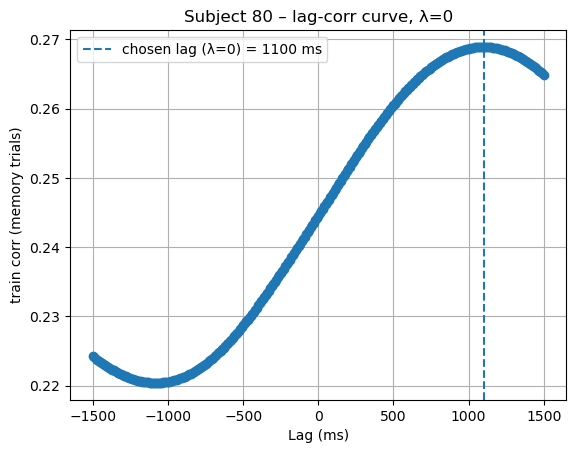

In [ ]:
def lag_corr_curve(trials, lam, shifts, trim_ms):
    rs = []
    for s in shifts:
        w_s, mse_tr, r_tr = fit_at_shift_lambda(trials, int(s), lam, trim_ms)
        rs.append(r_tr)
    return np.array(shifts) * 10, np.array(rs)

lags_ms0, rs0 = lag_corr_curve(trials_memory, 0.0, SHIFTS, trim_ms)

plt.figure()
plt.plot(lags_ms0, rs0, marker="o")
plt.axvline(lag_ms_zero, linestyle="--", label=f"chosen lag (λ=0) = {lag_ms_zero} ms")
plt.xlabel("Lag (ms)")
plt.ylabel("train corr (memory trials)")
plt.title(f"Subject {subj} – lag-corr curve, λ=0")
plt.grid(True)
plt.legend()
plt.show()
